# a)
a short description of your DQN design choices, including the network architecture, optimizer,
learning rate, batch size  

We first flatted the 2x6x7 board into an 84-d input vector, then passed through 2 ReLU activated hidden layers with 128 nodes each. Then the final linear output layer outputs one Q-value per column giving us 7 outputs. We used the Adam optimizer with a learning rate of 3e-4. We used a batch size of 128.

**Replay buffer:** capacity 50,000 transitions; training begins after 1,000 transitions are collected.

**Target network:** hard-copied from the online network every 250 gradient steps, which stabilizes bootstrapped TD targets.

**Epsilon schedule:** linear decay from 1.0 to 0.05 over 10,000 steps, then fixed — balancing early exploration with later exploitation.

**Discount factor:** γ = 1.0, treating all future rewards as equally weighted (appropriate given Connect 4 episodes are finite and relatively short).

**Legal-action masking:** Q-values for illegal columns are set to −10⁹ before the argmax, guaranteeing the agent never selects a full column.

 # gamma: float = 0.99
    # learning_rate: float = 3e-4
    # batch_size: int = 128
    # replay_capacity: int = 10000 #M for replay buffer capacity
    # min_replay_size: int = 1000 #minimum replay buffer size before starting optimization
    # target_sync_interval: int = 100 #C for target network sync
    # train_interval: int = 4     #N for number of environment steps between optimization updates for replay ratio
    # hidden_dim: int = 128  #set based on google search
    # epsilon_start: float = 1.0
    # epsilon_end: float = 0.05
    # epsilon_decay_steps: int = 10000
    # max_episodes: int = 50
    # eval_interval: int = 50
    # eval_games: int = 40
    # gradient_clip_norm: float = 5 # reduce to 1 if unstable
    # seed: int = 42

run # 1  
Training device: cpu
Checkpoint saved to: checkpoints\connect4_dqn.pt
Final episode: 10000
Final episode reward: 1.150
Final mean loss: 0.03483
Evaluation vs random: wins=30 losses=10 draws=0 win_rate=0.750

run # 2  

Training device: cpu  
Checkpoint saved to: checkpoints\connect4_dqn.pt  
Final episode: 10000  
Final episode reward: -0.700  
Final mean loss: 0.04852  
Evaluation vs random: wins=37 losses=3 draws=0 win_rate=0.925

ii. a plot of training progress; suitable choices include episode reward, moving-average reward,
training loss,

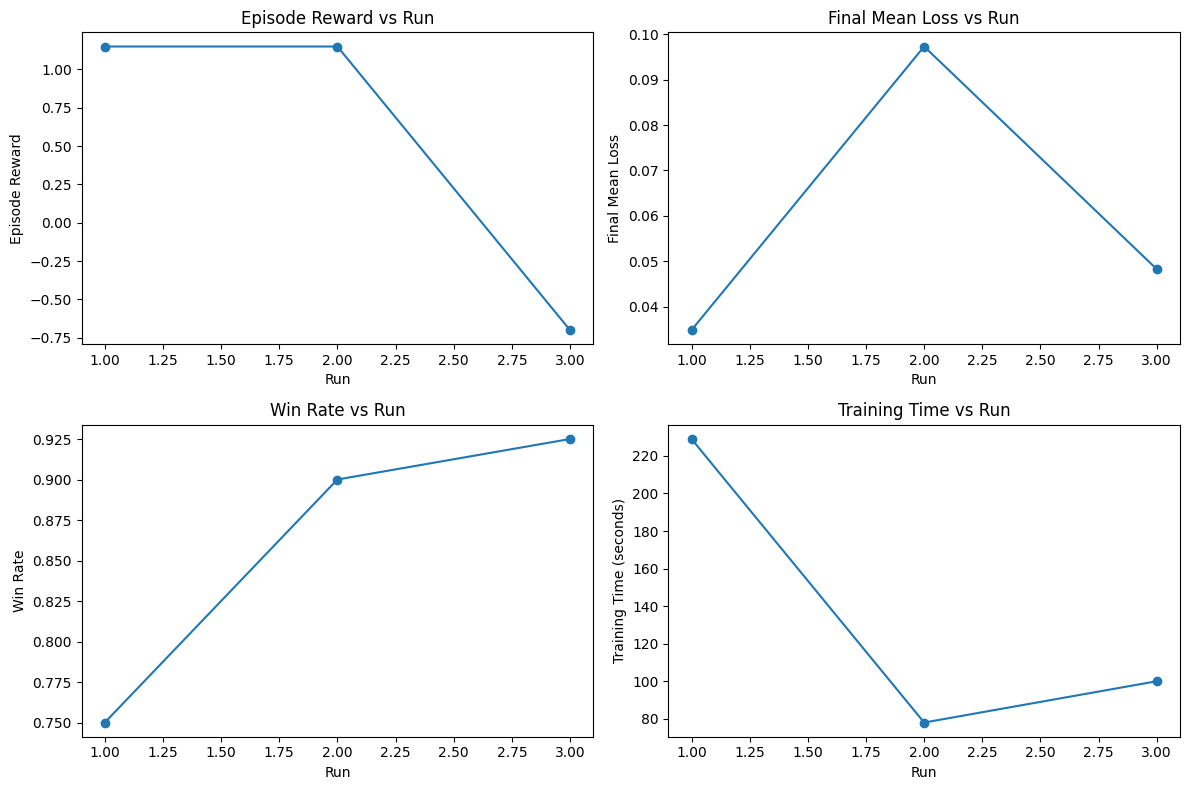

In [5]:
#read from csv
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read from csv
data = pd.read_csv('training_progress.csv')
#plot episode reward, final mean loss, win rate, training time vs run
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(data['Run'], data['Episode Reward'], marker='o')
plt.title('Episode Reward vs Run')
plt.xlabel('Run')
plt.ylabel('Episode Reward')
plt.subplot(2, 2, 2)
plt.plot(data['Run'], data['Final Mean Loss'], marker='o')
plt.title('Final Mean Loss vs Run')
plt.xlabel('Run') 
plt.ylabel('Final Mean Loss')
plt.subplot(2, 2, 3)
plt.plot(data['Run'], data['Win Rate'], marker='o')
plt.title('Win Rate vs Run')
plt.xlabel('Run')
plt.ylabel('Win Rate')
plt.subplot(2, 2, 4)
plt.plot(data['Run'], data['Training Time '], marker='o')
plt.title('Training Time vs Run')
plt.xlabel('Run')
plt.ylabel('Training Time (seconds)')
plt.tight_layout()
plt.show()




iii. your final win rate against the random opponent and the training time required to reach it

**win rate** = 92.5%  
**train_time** = 100 seconds

iv. a very short paragraph interpreting the training behavior you observe

During training we focused on tuning the learning rate, replay buffer capacity, and the target sync rate. Our optimal win-rate was found by decreasing the learning rate, and reducing replay buffer capacity and target sync interval. The results are interesting, because while this overall reduced our training time, and averge loss, we ended with a lower episode reward. 



# b)

i. a short description of your PPO design choices, including the policy and value architecture,
rollout length, minibatch size, number of epochs per update, clipping parameter,

ii. a plot of training progress

In [ ]:
#read from csv
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#read from csv
data = pd.read_csv('training_progress_ppo.csv')
#plot episode reward, final mean loss, win rate, training time vs run
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(data['Run'], data['Episode Reward'], marker='o')
plt.title('Episode Reward vs Run')
plt.xlabel('Run')
plt.ylabel('Episode Reward')
plt.subplot(2, 2, 2)
plt.plot(data['Run'], data['Final Mean Loss'], marker='o')
plt.title('Final Mean Loss vs Run')
plt.xlabel('Run') 
plt.ylabel('Final Mean Loss')
plt.subplot(2, 2, 3)
plt.plot(data['Run'], data['Win Rate'], marker='o')
plt.title('Win Rate vs Run')
plt.xlabel('Run')
plt.ylabel('Win Rate')
plt.subplot(2, 2, 4)
plt.plot(data['Run'], data['Training Time '], marker='o')
plt.title('Training Time vs Run')
plt.xlabel('Run')
plt.ylabel('Training Time (seconds)')
plt.tight_layout()
plt.show()

iii. your final win rate against the random opponent and the training time required to reach it

iv. a very short paragraph interpreting the training behavior you observe

# c)

Compare your DQN and PPO agents under roughly comparable computation budgets.
For example, you might train both for approximately similar wall-clock time on the same machine
(you do not need to retrain if you used training runs in a) and b) that took roughly similar
amounts of time). Which model performs better against the random opponent? Which model
was easier to tune the hyperparameters for?